<a href="https://colab.research.google.com/github/tejasmanojav/momentum_trading/blob/main/momentum_trading.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Can trading beat buy & hold?
I'm a buy & hold person (Bogle: just own the whole market and don't touch it). But many YouTube videos keep talking about simple trading strategies that are supposed to beat the market, or at least avoid the big crashes.

**Question:** Is that actually true for index ETFs?

**What I tested:** 20/50/100/200-day moving averages (with a 5% trailing stop), RSI (30/70), and my own "Confluence" strategy (200-day MA + RSI) on SPY, QQQ, DIA, IWM and VTI from 2004 to 2024. Everything is compared to just buying and holding.

**Sections:**
1. Data + settings
2. The strategies
3. Main results
4. Deep dives (stop-loss type, RSI settings, when Confluence buys, each ETF)
5. Real edge or just luck?
6. Conclusion
- Appendix A: Do other settings change the story?
- Appendix B: Sanity checks

# 1. Data + settings
**Settings:** 2% buffer around the MA (so tiny wiggles don't trigger trades), 5% trailing stop, RSI 14 with 30/70.

**How I picked them:** I started with the standard numbers everyone uses, tried a few nearby values by hand, and the results didn't change much, so I stuck with the standard ones. Appendix A redoes that check properly, with a table of other values.

In [ ]:
import yfinance as yf
import pandas as pd
import numpy as np

# 5 index ETFs: S&P 500, Nasdaq 100, Dow, small caps (Russell 2000), total US market
TARGET_TICKERS = ['SPY', 'QQQ', 'DIA', 'IWM', 'VTI']
START_DATE_STR = '2004-01-01'
END_DATE_STR = '2024-12-31'

MA_WINDOWS = {20: 'red', 50: 'green', 100: 'orange', 200: 'blue'}  # MA length -> chart color
EPSILON = 0.02            # 2% buffer around the MA
TRAILING_STOP_PCT = 0.05  # sell if price falls 5% from its high since I bought

RSI_WINDOW = 14
RSI_OVERSOLD = 30
RSI_OVERBOUGHT = 70

WARM_UP = 200  # skip the first 200 days so every strategy (incl. the 200-day MA) starts on the same day

data_dict = {}
for ticker in TARGET_TICKERS:
    print(f"Downloading {ticker}...")
    # auto_adjust=True: prices include dividends
    df = yf.download(ticker, start=START_DATE_STR, end=END_DATE_STR, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):  # newer yfinance returns 2-level column names
        df.columns = df.columns.get_level_values(0)
    data_dict[ticker] = df

print(f"\nDone: {', '.join(TARGET_TICKERS)}")


Done: SPY, QQQ, DIA, IWM, VTI


In [ ]:
# Quick look at the data
for ticker, df in data_dict.items():
    print(f"--- {ticker}: {len(df)} trading days ---")
    display(df.head(3))

--- SPY: 5284 trading days ---


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,73.461746,74.095777,73.131522,73.798572,38072300
2004-01-05,74.260872,74.313704,73.699486,73.765535,27959800
2004-01-06,74.333519,74.452400,73.970270,74.075944,20472800


--- QQQ: 5284 trading days ---


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,30.618292,30.980390,30.500400,30.870917,55234100
2004-01-05,31.233009,31.291955,30.786704,30.803546,69717900
2004-01-06,31.443552,31.510917,31.115138,31.224611,60033000


--- DIA: 5284 trading days ---


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,63.393471,64.061601,63.162659,63.800422,8231300
2004-01-05,64.128448,64.158815,63.654683,63.678975,6942600
2004-01-06,64.079758,64.176942,63.861097,63.927910,7702700


--- IWM: 5284 trading days ---


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,41.592751,41.830444,41.284493,41.288205,11182200
2004-01-05,42.079300,42.172149,41.711615,41.875030,8686000
2004-01-06,42.023575,42.387542,41.967865,42.105283,6196800


--- VTI: 5284 trading days ---


Price,Close,High,Low,Open,Volume
Date,,,,,
2004-01-02,35.616570,35.960933,35.526301,35.904097,390200
2004-01-05,36.014435,36.061241,35.813835,35.904104,368200
2004-01-06,36.138145,36.178266,35.944234,36.034503,244000


# 2. The strategies
**Trade timing:** I only see a signal after the market closes, so every trade happens at the **next day's** close.

**Helper functions:**
- Max drawdown, trade returns, ATR, RSI
- The MA strategy with a fixed % trailing stop, the same with an ATR stop, and RSI on its own

In [ ]:
import pandas as pd
import numpy as np

def calculate_max_drawdown(returns_series):
    """Biggest drop from a peak, e.g. -0.55 = fell 55% from the top."""
    if returns_series.empty:
        return 0
    growth = (1 + returns_series).cumprod()
    peak = growth.cummax()
    return (growth / peak - 1).min()

def calculate_trade_returns(trade_events_df):
    """Turns a list of BUY/SELL signals into one return per trade."""
    trades = []
    df = trade_events_df.reset_index()
    if len(df) % 2 != 0:  # safety: ignore an unmatched last row
        df = df.iloc[:-1]
    px = 'Exec_Close' if 'Exec_Close' in df.columns else 'Close'  # next-day price (see add_execution_prices)
    for i in range(0, len(df), 2):
        entry, exit = df.iloc[i], df.iloc[i + 1]
        if entry['Trade'] == 'BUY':
            trades.append({'ExitDate': exit['Date'], 'Return_Pct': exit[px] / entry[px] - 1})
    return pd.DataFrame(trades)

def calculate_atr(df, window=14):
    """ATR = average daily price range over the last 14 days (how jumpy the price is)."""
    high, low, close_prev = df['High'], df['Low'], df['Close'].shift(1)
    true_range = pd.concat([high - low, (high - close_prev).abs(), (low - close_prev).abs()], axis=1).max(axis=1)
    df['ATR'] = true_range.rolling(window=window).mean()
    return df

def calculate_rsi(df, window=14):
    """RSI (0-100): below 30 = fell a lot lately ('oversold'), above 70 = rose a lot ('overbought')."""
    delta = df['Close'].diff()
    gain = delta.where(delta > 0, 0).rolling(window=window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=window).mean()
    rs = np.where(loss == 0, np.inf, gain / loss)
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

def add_execution_prices(trade_df, price_df):
    """Add the price I actually trade at: the NEXT day's close.
    On the last day there's no next day, so use that day's close."""
    if trade_df.empty:
        return trade_df
    next_close = price_df['Close'].shift(-1).fillna(price_df['Close'])
    trade_df = trade_df.copy()
    trade_df['Exec_Close'] = next_close.reindex(trade_df.index).values
    return trade_df

def close_open_position(signals, price_df):
    """If I'm still holding on the last day, sell at the last price so the trade still counts."""
    if signals and signals[-1]['Trade'] == 'BUY':
        last_date = price_df.index[-1]
        if signals[-1]['Date'] == last_date:
            signals.pop()  # bought on the very last day, nothing to count
        else:
            signals.append({'Date': last_date, 'Close': price_df['Close'].iloc[-1], 'Trade': 'SELL'})
    return signals

def add_rsi_signals(df, oversold=30, overbought=70):
    """RSI only: buy when RSI < oversold, sell when RSI > overbought."""
    temp = calculate_rsi(df.copy())
    signals = []
    last_signal = None
    for i in range(len(temp)):
        rsi = temp['RSI'].iloc[i]
        if rsi < oversold and last_signal != 'BUY':
            signals.append({'Date': temp.index[i], 'Close': temp['Close'].iloc[i], 'Trade': 'BUY'})
            last_signal = 'BUY'
        elif rsi > overbought and last_signal == 'BUY':
            signals.append({'Date': temp.index[i], 'Close': temp['Close'].iloc[i], 'Trade': 'SELL'})
            last_signal = None
    signals = close_open_position(signals, temp)
    return add_execution_prices(pd.DataFrame(signals).set_index('Date'), temp) if signals else pd.DataFrame()

def trade_ma_with_fixed_trailing_stop(df, window_length, epsilon=0.02, trailing_stop_pct=0.05):
    """Buy when price > MA + 2%.
    Sell when price < MA - 2%, or when it falls 5% from its high since I bought (trailing stop)."""
    temp = df.copy()
    temp['MA'] = temp['Close'].rolling(window=window_length).mean()
    signals, current_pos, stop_loss = [], None, 0
    valid_df = temp[temp['MA'].notna()].copy()

    for i in range(len(valid_df)):
        price = valid_df['Close'].iloc[i]
        m = valid_df['MA'].iloc[i]
        if current_pos is None:
            if price > m * (1 + epsilon):
                signals.append({'Date': valid_df.index[i], 'Close': price, 'Trade': 'BUY'})
                current_pos = 'LONG'
                stop_loss = price * (1 - trailing_stop_pct)
        elif current_pos == 'LONG':
            stop_loss = max(stop_loss, price * (1 - trailing_stop_pct))  # stop only moves up
            if price < m * (1 - epsilon) or price < stop_loss:
                signals.append({'Date': valid_df.index[i], 'Close': price, 'Trade': 'SELL'})
                current_pos = None
    signals = close_open_position(signals, temp)
    return add_execution_prices(pd.DataFrame(signals).set_index('Date'), temp) if signals else pd.DataFrame()

def trade_ma_with_atr_stop(df, window_length, epsilon=0.02, atr_multiplier=2.0):
    """Same as above, but the stop is (multiplier x ATR) below the price instead of a fixed 5%."""
    temp = df.copy()
    temp['MA'] = temp['Close'].rolling(window=window_length).mean()
    temp = calculate_atr(temp)
    signals, current_pos, stop_loss = [], None, 0
    valid_df = temp[temp['MA'].notna() & temp['ATR'].notna()].copy()

    for i in range(len(valid_df)):
        price = valid_df['Close'].iloc[i]
        m = valid_df['MA'].iloc[i]
        atr = valid_df['ATR'].iloc[i]
        if current_pos is None:
            if price > m * (1 + epsilon):
                signals.append({'Date': valid_df.index[i], 'Close': price, 'Trade': 'BUY'})
                current_pos = 'LONG'
                stop_loss = price - (atr * atr_multiplier)
        elif current_pos == 'LONG':
            stop_loss = max(stop_loss, price - (atr * atr_multiplier))  # stop only moves up
            if price < m * (1 - epsilon) or price < stop_loss:
                signals.append({'Date': valid_df.index[i], 'Close': price, 'Trade': 'SELL'})
                current_pos = None
    signals = close_open_position(signals, temp)
    return add_execution_prices(pd.DataFrame(signals).set_index('Date'), temp) if signals else pd.DataFrame()

### My strategy: Confluence (200-day MA + RSI)
**Idea:** Only buy dips when the long-term trend is up. Only sell when the trend is down AND price has bounced too far.
- **BUY:** price > 200-day MA (+2%) and RSI < 30
- **SELL:** price < 200-day MA (-2%) and RSI > 70

**Why it might work:** The MA keeps me out of buying in a downtrend, and RSI waits for a dip instead of buying at the top.

**Question:** Does combining trend + RSI beat either one alone? (Answered in Section 3.)

In [ ]:
def trade_confluence(df, window_ma=200, rsi_os=30, rsi_ob=70, epsilon=0.02):
    """BUY:  price > MA + 2%  AND  RSI < 30
       SELL: price < MA - 2%  AND  RSI > 70"""
    df = df.copy()
    ma_col = f'MA_{window_ma}'
    df[ma_col] = df['Close'].rolling(window=window_ma).mean()
    df = calculate_rsi(df)

    in_uptrend = df['Close'] > df[ma_col] * (1 + epsilon)
    in_downtrend = df['Close'] < df[ma_col] * (1 - epsilon)
    oversold = df['RSI'] < rsi_os
    overbought = df['RSI'] > rsi_ob

    df['Trade'] = None
    last_signal = None
    for i in range(1, len(df)):
        if in_uptrend.iloc[i] and oversold.iloc[i]:
            if last_signal != 'BUY':
                df.at[df.index[i], 'Trade'] = 'BUY'
                last_signal = 'BUY'
        elif in_downtrend.iloc[i] and overbought.iloc[i]:
            if last_signal == 'BUY':  # can only sell if I own it
                df.at[df.index[i], 'Trade'] = 'SELL'
                last_signal = 'SELL'

    # Still holding on the last day? Sell at the last price so the trade counts.
    if last_signal == 'BUY':
        last_idx = df.index[-1]
        if df.at[last_idx, 'Trade'] == 'BUY':
            df.at[last_idx, 'Trade'] = None  # bought on the very last day, nothing to count
        else:
            df.at[last_idx, 'Trade'] = 'SELL'

    return add_execution_prices(df[df['Trade'].notna()][['Close', 'Trade']], df)

# 3. Main results
**Question:** With the same rules for everyone, which strategy does best?
- Same start date (first 200 days skipped), next-day trades, compounded daily returns
- Results averaged over the 5 ETFs

**What to test:** Total return, max drawdown, Sharpe ratio (return per unit of risk), and win rate.

In [ ]:
def calculate_sharpe_ratio(daily_returns, risk_free_rate=0.0):
    """Return per unit of risk, per year: average daily return / daily std dev x sqrt(252 trading days)."""
    if daily_returns.empty or daily_returns.std() == 0:
        return 0
    return (daily_returns.mean() - risk_free_rate) / daily_returns.std() * np.sqrt(252)

def get_daily_strategy_returns(df, trades_df):
    """The ETF's daily return on days I'm holding, 0 on days I'm in cash."""
    pos = pd.Series(0, index=df.index)
    if trades_df.empty:
        return pos.astype(float)
    for i in range(0, len(trades_df) - 1, 2):
        entry_date, exit_date = trades_df.index[i], trades_df.index[i + 1]
        pos.loc[entry_date:exit_date] = 1
        pos.loc[exit_date] = 0
    # Signal at day t's close -> trade at day t+1's close -> first return I actually get is day t+2
    return pos.shift(2).fillna(0) * df['Close'].pct_change().fillna(0)

# Every strategy, in one place (reused by later sections)
STRATEGIES = {f'{w}-Day MA': (lambda d, w=w: trade_ma_with_fixed_trailing_stop(
                  d, w, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT))
              for w in MA_WINDOWS}
STRATEGIES['RSI (30/70)'] = lambda d: add_rsi_signals(d, oversold=RSI_OVERSOLD, overbought=RSI_OVERBOUGHT)
STRATEGIES['Confluence'] = lambda d: trade_confluence(
    d, window_ma=200, rsi_os=RSI_OVERSOLD, rsi_ob=RSI_OVERBOUGHT, epsilon=EPSILON)

# Run every strategy on every ETF once and keep the trades
TRADES = {(name, t): fn(data_dict[t]) for name, fn in STRATEGIES.items() for t in TARGET_TICKERS}

rows = []
for t, df in data_dict.items():
    bh = df.iloc[WARM_UP:]
    bh_daily = bh['Close'].pct_change().dropna()
    bh_total = bh['Close'].iloc[-1] / bh['Close'].iloc[0] - 1
    rows.append({'Ticker': t, 'Strategy': 'Buy & Hold', 'Total Return': bh_total,
                 'Max Drawdown': calculate_max_drawdown(bh_daily),
                 'Sharpe Ratio': calculate_sharpe_ratio(bh_daily),
                 'Win Rate (%)': 100.0, 'Avg Return/Trade': bh_total, 'Std Dev/Trade': 0.0, 'Trades': 1})

    for name in STRATEGIES:
        trades = TRADES[(name, t)]
        if trades.empty:
            continue
        daily = get_daily_strategy_returns(df, trades).iloc[WARM_UP:]
        rets = calculate_trade_returns(trades)['Return_Pct']
        rows.append({'Ticker': t, 'Strategy': name,
                     'Total Return': (1 + daily).prod() - 1,
                     'Max Drawdown': calculate_max_drawdown(daily),
                     'Sharpe Ratio': calculate_sharpe_ratio(daily),
                     'Win Rate (%)': (rets > 0).mean() * 100,
                     'Avg Return/Trade': rets.mean(),
                     'Std Dev/Trade': rets.std(),
                     'Trades': len(rets)})

master_results = pd.DataFrame(rows)
main_summary = master_results.groupby('Strategy').agg({
    'Total Return': 'mean', 'Max Drawdown': 'mean', 'Sharpe Ratio': 'mean', 'Win Rate (%)': 'mean',
    'Avg Return/Trade': 'mean', 'Std Dev/Trade': 'mean', 'Trades': 'sum'
}).sort_values('Sharpe Ratio', ascending=False)

print('--- All strategies, averaged over the 5 ETFs (Trades = total over all 5) ---')
display(main_summary.round(3))

--- All strategies, averaged over the 5 ETFs (Trades = total over all 5) ---


,Total Return,Max Drawdown,Sharpe Ratio,Win Rate (%),Avg Return/Trade,Std Dev/Trade,Trades
Strategy,,,,,,,
Confluence,5.480,-0.343,0.658,87.619,0.371,0.354,32
200-Day MA,3.537,-0.238,0.642,52.452,0.029,0.092,307
Buy & Hold,7.910,-0.549,0.619,100.000,7.910,0.000,5
50-Day MA,2.532,-0.244,0.563,51.150,0.022,0.078,315
100-Day MA,2.250,-0.260,0.528,51.019,0.023,0.085,305
20-Day MA,1.988,-0.317,0.476,49.503,0.015,0.069,422
RSI (30/70),2.154,-0.450,0.426,81.348,0.025,0.066,270


### Results per ETF
**Question:** Is one ETF (probably QQQ) carrying the averages?

**What to test:** Total return and max drawdown for each ETF separately.

In [ ]:
print('--- Total return per ETF ---')
display(master_results.pivot_table(index='Strategy', columns='Ticker', values='Total Return').round(2))

print('\n--- Max drawdown per ETF ---')
display(master_results.pivot_table(index='Strategy', columns='Ticker', values='Max Drawdown').round(2))

--- Total return per ETF ---


Ticker,DIA,IWM,QQQ,SPY,VTI
Strategy,,,,,
100-Day MA,1.09,1.14,3.58,2.65,2.80
20-Day MA,1.22,0.50,3.92,2.27,2.03
200-Day MA,2.03,1.69,6.09,3.87,4.01
50-Day MA,1.63,1.05,4.92,2.49,2.57
Buy & Hold,5.79,4.13,15.92,6.80,6.91
Confluence,4.26,2.81,11.03,4.47,4.83
RSI (30/70),1.29,3.44,1.98,2.09,1.97



--- Max drawdown per ETF ---


Ticker,DIA,IWM,QQQ,SPY,VTI
Strategy,,,,,
100-Day MA,-0.20,-0.37,-0.28,-0.22,-0.22
20-Day MA,-0.27,-0.36,-0.31,-0.33,-0.31
200-Day MA,-0.22,-0.29,-0.29,-0.18,-0.22
50-Day MA,-0.23,-0.33,-0.22,-0.22,-0.21
Buy & Hold,-0.52,-0.59,-0.53,-0.55,-0.55
Confluence,-0.37,-0.37,-0.29,-0.34,-0.35
RSI (30/70),-0.50,-0.34,-0.46,-0.47,-0.48


### Everything as one portfolio
**Question:** What does it look like if I split my money equally across all 5 ETFs?

**What to test:** Growth of each strategy vs. buy & hold over time.

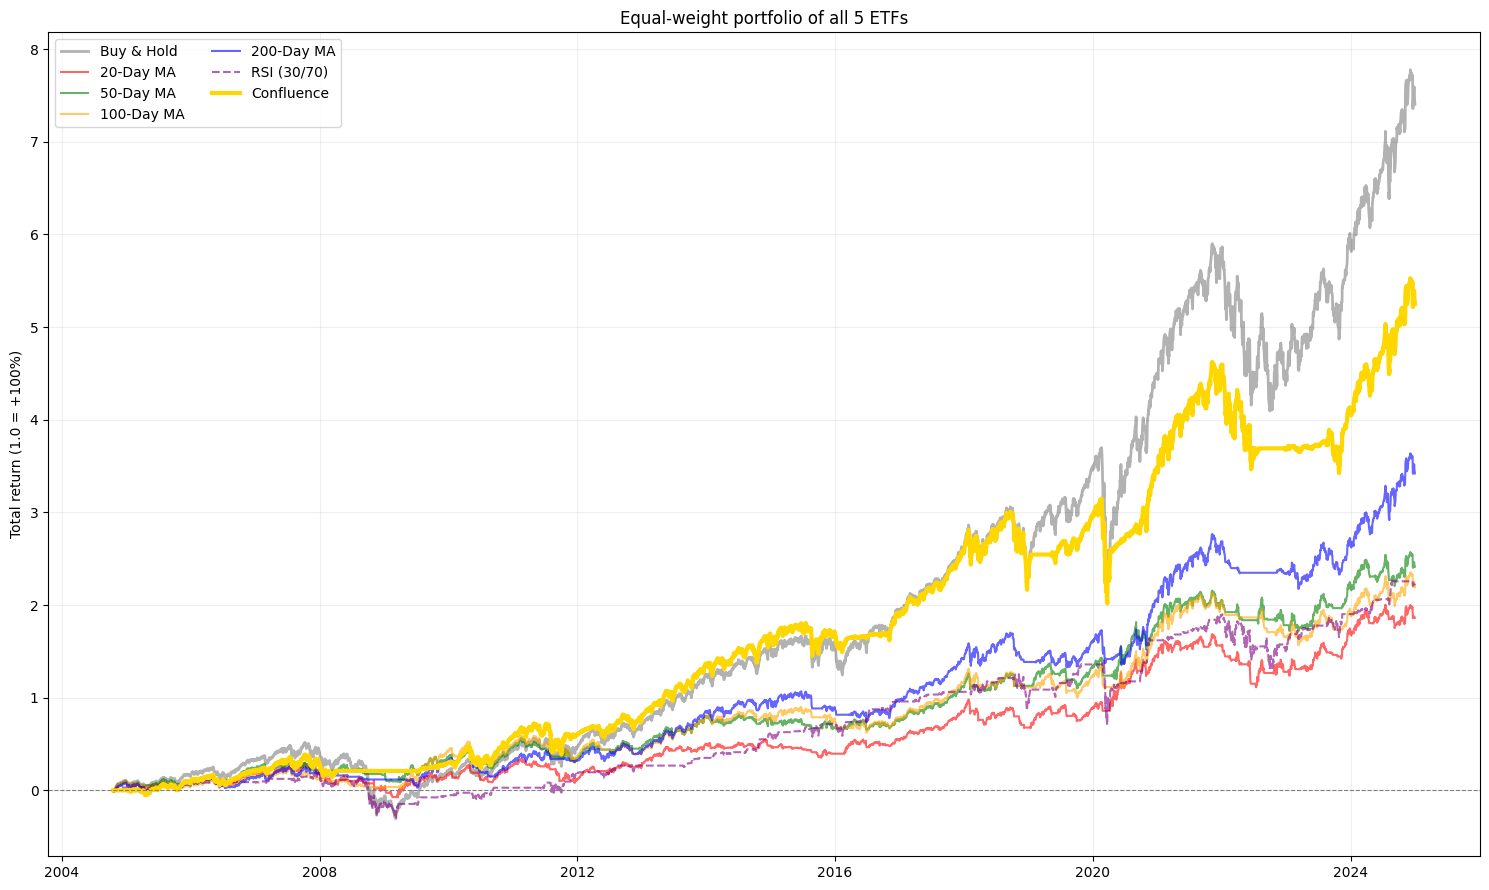

In [ ]:
import matplotlib.pyplot as plt

def portfolio_growth(daily_returns_list):
    """Equal money in each ETF: average the daily returns, then compound."""
    avg_daily = pd.concat(daily_returns_list, axis=1).mean(axis=1)
    return (1 + avg_daily).cumprod() - 1

portfolio_equity = {'Buy & Hold': portfolio_growth(
    [data_dict[t]['Close'].pct_change().iloc[WARM_UP:] for t in TARGET_TICKERS])}
for name in STRATEGIES:
    portfolio_equity[name] = portfolio_growth(
        [get_daily_strategy_returns(data_dict[t], TRADES[(name, t)]).iloc[WARM_UP:] for t in TARGET_TICKERS])

COLORS = {f'{w}-Day MA': c for w, c in MA_WINDOWS.items()}
COLORS.update({'RSI (30/70)': 'purple', 'Confluence': 'gold'})

plt.figure(figsize=(15, 9))
plt.plot(portfolio_equity['Buy & Hold'], label='Buy & Hold', color='black', linewidth=2, alpha=0.3)
for name in STRATEGIES:
    is_mine = name == 'Confluence'
    plt.plot(portfolio_equity[name], label=name, color=COLORS[name],
             linewidth=3 if is_mine else 1.5, alpha=1 if is_mine else 0.6,
             linestyle='--' if name.startswith('RSI') else '-')
plt.title('Equal-weight portfolio of all 5 ETFs')
plt.ylabel('Total return (1.0 = +100%)')
plt.axhline(0, color='grey', linewidth=0.8, linestyle='--')
plt.legend(loc='upper left', ncol=2)
plt.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

### What I found (main results)
- **Nothing beats buy & hold on total return.** Buy & hold: ~791%. Confluence: ~548%. 200-day MA: ~354%. It's the same on every single ETF.
- **The strategies do cut the crashes.** Max drawdown is ~-24% (200-day MA) and ~-34% (Confluence) vs. ~-55% for buy & hold.
- **Sharpe ratios are all close** (~0.43 to ~0.66). Confluence and the 200-day MA are at the top, just above buy & hold. RSI is last (~0.43), and its drawdown (~-45%) isn't much better than buy & hold, so it doesn't even protect you much in a crash.
- **Shorter MA = worse.** The 20-day MA trades the most and does the worst.
- **Combining helps (mostly).** Confluence beats the 200-day MA on all 5 ETFs, and beats RSI alone on 4 of 5. The exception is IWM (small caps), where plain RSI did better (~344% vs. ~281%). Section 5 checks whether Confluence's lead is just luck.
- **QQQ carries everything.** It has the biggest return for every strategy, and IWM (small caps) has the smallest.
- **Confluence basically became buy & hold.** In the chart, from 2009 to 2019 its line is almost on top of buy & hold, because the sell rule hardly ever fires (~6 trades per ETF in 20 years). It only differed in 2008 (it was out, which helped), 2020 (it rode the COVID crash all the way down, which is where the -34% comes from), and 2022-23 (it got out, then missed the start of the rebound).

# 4. Deep dives

## 4a. Which stop-loss? (fixed % vs. ATR)
**Question:** People say an ATR stop (based on how jumpy the price is) is smarter than a fixed %. Is it?

**What to test:** Fixed 5% vs. 2x ATR on all 4 MAs.

*Note: "Max DD (trade-level)" only looks at trade-to-trade changes, so it looks smaller than the max drawdown in Section 3.*

In [ ]:
rows = []
for t, df in data_dict.items():
    for window in MA_WINDOWS:
        stops = {
            'Fixed 5%': trade_ma_with_fixed_trailing_stop(df, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT),
            'ATR 2.0x': trade_ma_with_atr_stop(df, window, epsilon=EPSILON, atr_multiplier=2.0),
        }
        for stop_name, trades in stops.items():
            rets = calculate_trade_returns(trades)
            if rets.empty:
                continue
            rows.append({'MA': window, 'Stop': stop_name, 'Ticker': t,
                         'Total Return': (1 + rets['Return_Pct']).prod() - 1,
                         'Max DD (trade-level)': calculate_max_drawdown(rets['Return_Pct']),
                         'Trades': len(rets)})

stop_comparison = pd.DataFrame(rows).groupby(['MA', 'Stop'])[['Total Return', 'Max DD (trade-level)', 'Trades']].mean()
print('--- Fixed 5% vs. 2x ATR (averaged over 5 ETFs; Trades = per ETF) ---')
display(stop_comparison.round(2))

--- Fixed 5% vs. 2x ATR (averaged over 5 ETFs; Trades = per ETF) ---


Total Return  Max DD (trade-level)  Trades
MA  Stop                                                
20  ATR 2.0x          1.15                 -0.23   118.6
    Fixed 5%          1.90                 -0.27    84.4
50  ATR 2.0x          1.35                 -0.19   146.0
    Fixed 5%          2.33                 -0.19    63.0
100 ATR 2.0x          1.87                 -0.23   176.6
    Fixed 5%          2.19                 -0.19    61.0
200 ATR 2.0x          2.87                 -0.22   194.6
    Fixed 5%          3.54                 -0.17    61.4

### Why does the 200-day MA trade so much?
**Question:** In the table above, the 200-day MA trades almost as often as the 50-day (~61 vs. ~63 trades per ETF). Is the price just hanging around the 200-day line?

**What to test:** Count raw crossovers vs. my strategy's signals (with the 2% buffer). Also check how far price usually is from each MA.

In [ ]:
def analyze_ma_frequency(ticker, windows=(50, 200)):
    df = data_dict[ticker]
    rows = []
    for w in windows:
        ma = df['Close'].rolling(window=w).mean()
        # Raw crossovers: days where price crosses the MA (no buffer, no stop)
        cross_up = (df['Close'] > ma) & (df['Close'].shift(1) <= ma.shift(1))
        cross_down = (df['Close'] < ma) & (df['Close'].shift(1) >= ma.shift(1))
        signals = trade_ma_with_fixed_trailing_stop(df, w, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)
        rows.append({'MA': w,
                     'Raw crossovers': int(cross_up.sum() + cross_down.sum()),
                     'My signals (buys + sells)': len(signals),
                     'Avg distance from MA (%)': ((df['Close'] - ma).abs() / ma).mean() * 100})
    print(f'--- {ticker} ---')
    display(pd.DataFrame(rows).round(2))

analyze_ma_frequency('SPY')
analyze_ma_frequency('QQQ')

--- SPY ---


,MA,Raw crossovers,My signals (buys + sells),Avg distance from MA (%)
0,50,368,106,3.04
1,200,130,98,7.32


--- QQQ ---


,MA,Raw crossovers,My signals (buys + sells),Avg distance from MA (%)
0,50,339,130,3.90
1,200,138,152,9.27


### Fixed 5% stop vs. ATR stop over time (SPY)
**Question:** What do the two stop types actually look like over time?

**What to test:** Plot both for the 200-day MA on SPY. (The line only moves when a trade closes.)

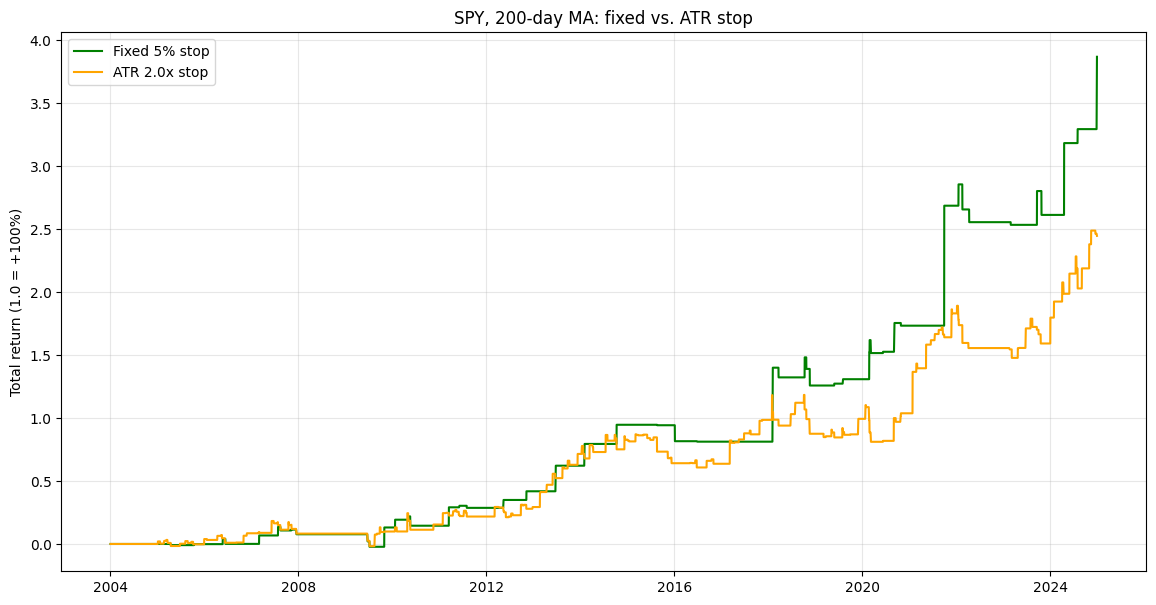

In [ ]:
import matplotlib.pyplot as plt

def plot_stop_comparison(ticker, window=200):
    df = data_dict[ticker]
    versions = {
        f'Fixed {TRAILING_STOP_PCT:.0%} stop': (trade_ma_with_fixed_trailing_stop(
            df, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT), 'green'),
        'ATR 2.0x stop': (trade_ma_with_atr_stop(df, window, epsilon=EPSILON, atr_multiplier=2.0), 'orange'),
    }
    plt.figure(figsize=(14, 7))
    for label, (trades, color) in versions.items():
        if trades.empty:
            continue
        rets = calculate_trade_returns(trades)
        growth = pd.Series(0.0, index=df.index)
        growth.loc[rets['ExitDate']] = rets['Return_Pct'].values
        plt.plot((1 + growth).cumprod() - 1, label=label, color=color)
    plt.title(f'{ticker}, {window}-day MA: fixed vs. ATR stop')
    plt.ylabel('Total return (1.0 = +100%)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_stop_comparison('SPY', window=200)

### Why is the ATR stop worse?
**Question:** Is the 2x ATR stop just too tight?

**What to test:** How far below the price the 2x ATR stop usually is, vs. the fixed 5%.

--- How far below the price is the stop? (SPY) ---
Fixed stop:              5.00%
2.0x ATR stop (average): 2.68%


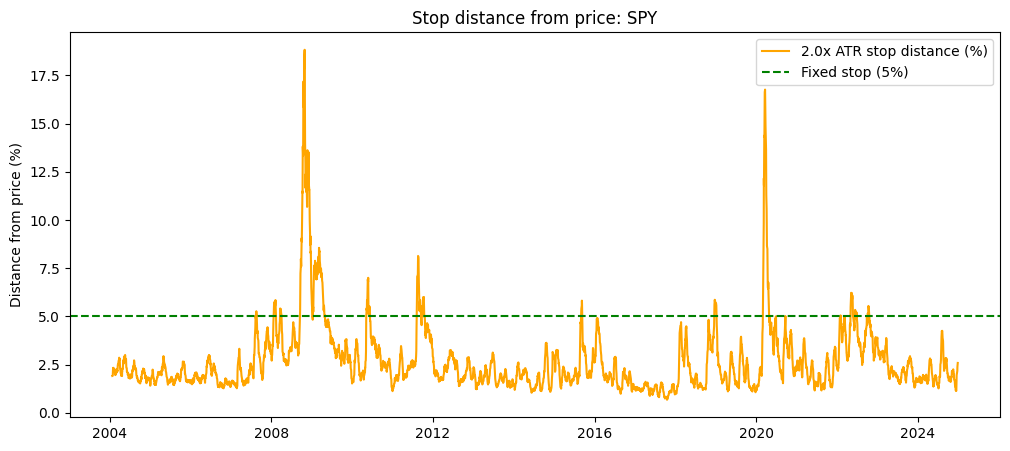

In [ ]:
def analyze_stop_tightness(ticker, atr_multiplier=2.0):
    df = calculate_atr(data_dict[ticker].copy())
    atr_dist = df['ATR'] * atr_multiplier / df['Close'] * 100  # stop distance as % of price

    print(f'--- How far below the price is the stop? ({ticker}) ---')
    print(f'Fixed stop:              {TRAILING_STOP_PCT * 100:.2f}%')
    print(f'{atr_multiplier}x ATR stop (average): {atr_dist.mean():.2f}%')

    plt.figure(figsize=(12, 5))
    plt.plot(atr_dist, label=f'{atr_multiplier}x ATR stop distance (%)', color='orange')
    plt.axhline(y=TRAILING_STOP_PCT * 100, color='green', linestyle='--', label=f'Fixed stop ({TRAILING_STOP_PCT:.0%})')
    plt.title(f'Stop distance from price: {ticker}')
    plt.ylabel('Distance from price (%)')
    plt.legend()
    plt.show()

analyze_stop_tightness('SPY')

### Does the tighter stop cause more trades?
**Question:** If the ATR stop is tighter, does it get kicked out of good trades more often?

**What to test:** Number of trades and how often a trade happens, fixed vs. ATR (SPY, 200-day MA).

In [ ]:
def analyze_churn(ticker, window=200):
    df = data_dict[ticker]
    versions = {
        'Fixed 5% stop': trade_ma_with_fixed_trailing_stop(df, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT),
        'ATR 2.0x stop': trade_ma_with_atr_stop(df, window, epsilon=EPSILON, atr_multiplier=2.0),
    }
    counts = {}
    print(f'--- How often does each stop trade? ({ticker}, {window}-day MA) ---')
    for label, trades in versions.items():
        counts[label] = len(calculate_trade_returns(trades))
        # Total days / trades = how often a trade happens (includes days in cash, so it's NOT holding time)
        print(f'{label}: {counts[label]} trades -> one trade every ~{len(df) / counts[label]:.0f} days')
    print(f"ATR 2.0x makes {counts['ATR 2.0x stop'] / counts['Fixed 5% stop']:.1f}x as many trades")

analyze_churn('SPY')

--- How often does each stop trade? (SPY, 200-day MA) ---
Fixed 5% stop: 49 trades -> one trade every ~108 days
ATR 2.0x stop: 195 trades -> one trade every ~27 days
ATR 2.0x makes 4.0x as many trades


### What if I make the ATR stop wider?
**Question:** Does ATR work better if I give it more room?

**What to test:** ATR 2.0x / 3.5x / 4.0x vs. fixed 5%, on the 50-day and 200-day MA.

In [ ]:
ATR_MULTIPLIERS = [2.0, 3.5, 4.0]
rows = []
for t, df in data_dict.items():
    for window in [50, 200]:
        stops = {'Fixed 5%': trade_ma_with_fixed_trailing_stop(df, window, epsilon=EPSILON, trailing_stop_pct=TRAILING_STOP_PCT)}
        for mult in ATR_MULTIPLIERS:
            stops[f'ATR {mult}x'] = trade_ma_with_atr_stop(df, window, epsilon=EPSILON, atr_multiplier=mult)
        for stop_name, trades in stops.items():
            rets = calculate_trade_returns(trades)
            if rets.empty:
                continue
            rows.append({'MA': window, 'Stop': stop_name, 'Ticker': t,
                         'Total Return': (1 + rets['Return_Pct']).prod() - 1,
                         'Max DD (trade-level)': calculate_max_drawdown(rets['Return_Pct']),
                         'Trades': len(rets)})

wider_atr = pd.DataFrame(rows).groupby(['MA', 'Stop'])[['Total Return', 'Max DD (trade-level)', 'Trades']].mean().reset_index()
print('--- Fixed 5% vs. wider ATR stops (averaged over 5 ETFs; Trades = per ETF) ---')
display(wider_atr.sort_values(['MA', 'Total Return'], ascending=[True, False]).round(2))

--- Fixed 5% vs. wider ATR stops (averaged over 5 ETFs; Trades = per ETF) ---


,MA,Stop,Total Return,Max DD (trade-level),Trades
3,50,Fixed 5%,2.33,-0.19,63.0
1,50,ATR 3.5x,1.89,-0.21,78.2
2,50,ATR 4.0x,1.78,-0.22,70.2
0,50,ATR 2.0x,1.35,-0.19,146.0
5,200,ATR 3.5x,3.59,-0.19,89.6
7,200,Fixed 5%,3.54,-0.17,61.4
6,200,ATR 4.0x,3.46,-0.19,75.8
4,200,ATR 2.0x,2.87,-0.22,194.6


### What I found (stops)
- **Why the 200-day MA trades so much:** it's not the MA line. On SPY the 2% buffer only cuts 200-day signals from 130 crossovers to 98, and price is usually ~7% away from the 200-day line. My guess is the 5% trailing stop: after a stop-out, if price is still above the MA + 2%, it buys right back the next day. On QQQ my strategy actually makes **more** signals (152) than there are raw crossovers (138), which only makes sense if the stop is adding extra trades. (I haven't tested this directly.)
- **The 2x ATR stop is too tight.** It's only ~2.7% below the price on SPY (vs. 5%), so it gets stopped out a lot: 195 trades vs. 49 (one trade every ~27 days vs. every ~108 days).
- **Wider ATR (3.5x-4.0x) fixes most of that** and ends up about even with the fixed 5% on the 200-day MA.
- **On the 50-day MA the fixed 5% stop wins clearly.**
- **Takeaway:** the multiplier matters more than ATR vs. fixed. I'm keeping the fixed 5% because it's simpler.

### Notes (for the report)
The ranking on the 200-day MA changed when I fixed the trade timing (trading at the signal day's close vs. the next day's close):

| 200-day MA stop | Same-day close | Next-day close |
|---|---|---|
| ATR 4.0x | **384%** (1st) | 346% (3rd) |
| Fixed 5% | 374% (2nd) | 354% (2nd) |
| ATR 3.5x | 360% (3rd) | **359%** (1st) |
| ATR 2.0x | 275% (4th) | 288% (4th) |

- Just moving every trade by one day reshuffled the top 3, so the gaps between them (~10-20%) are basically noise.
- Even re-downloading the same data moved ATR 3.5x around (366%, then 362%, then 359%) because of tiny differences in the downloaded prices. More proof that small gaps don't mean much.
- ATR 2.0x is last both times, so "too tight is bad" is a real result.
- On the 50-day MA, fixed 5% was 1st both times (221% / 233%).

## 4b. RSI settings
**Question:** Does RSI work better with different levels than 30/70?

**What to test:** RSI 30/70 vs. 20/80 (stricter) vs. 40/60 (looser), on all 5 ETFs.

In [ ]:
rsi_variants = [(30, 70), (20, 80), (40, 60)]
rows = []
for oversold, overbought in rsi_variants:
    for t in TARGET_TICKERS:
        rets = calculate_trade_returns(add_rsi_signals(data_dict[t], oversold=oversold, overbought=overbought))
        if rets.empty:
            continue
        rows.append({'RSI levels': f'{oversold}/{overbought}', 'Ticker': t,
                     'Total Return': (1 + rets['Return_Pct']).prod() - 1,
                     'Trades': len(rets),
                     'Win Rate (%)': (rets['Return_Pct'] > 0).mean() * 100})

rsi_summary = pd.DataFrame(rows).groupby('RSI levels').agg(
    {'Total Return': 'mean', 'Trades': 'sum', 'Win Rate (%)': 'mean'}).sort_values('Total Return', ascending=False)
print('--- RSI levels (averaged over 5 ETFs; Trades = total) ---')
display(rsi_summary.round(2))

--- RSI levels (averaged over 5 ETFs; Trades = total) ---


,Total Return,Trades,Win Rate (%)
RSI levels,,,
30/70,2.34,270,81.35
40/60,2.32,503,76.03
20/80,0.80,86,81.62


### What I found (RSI)
- **30/70 and 40/60 are about the same** (~234% vs. ~232%). 20/80 hardly ever trades (~86 trades total) and makes much less (~80%).
- **High win rate doesn't mean high return.** RSI wins ~81% of its trades but still makes way less than buy & hold. It sells too early, sits in cash, and misses the big runs.
- **RSI likes small caps.** On IWM, plain RSI (~344%) beat every other strategy except buy & hold. On QQQ it was the worst (~198%). Maybe small caps bounce back after dips more, and QQQ just keeps going up.

## 4c. When does Confluence buy?
**Question:** How often does my BUY rule actually light up?

**What to test:** For the last ~4 years, show when price is in an uptrend (green) and when RSI is below 30 (blue). A "!" means both are true, so the BUY condition is on. These are **not** trades: once I own it, extra "!"s don't do anything, and sells aren't shown.

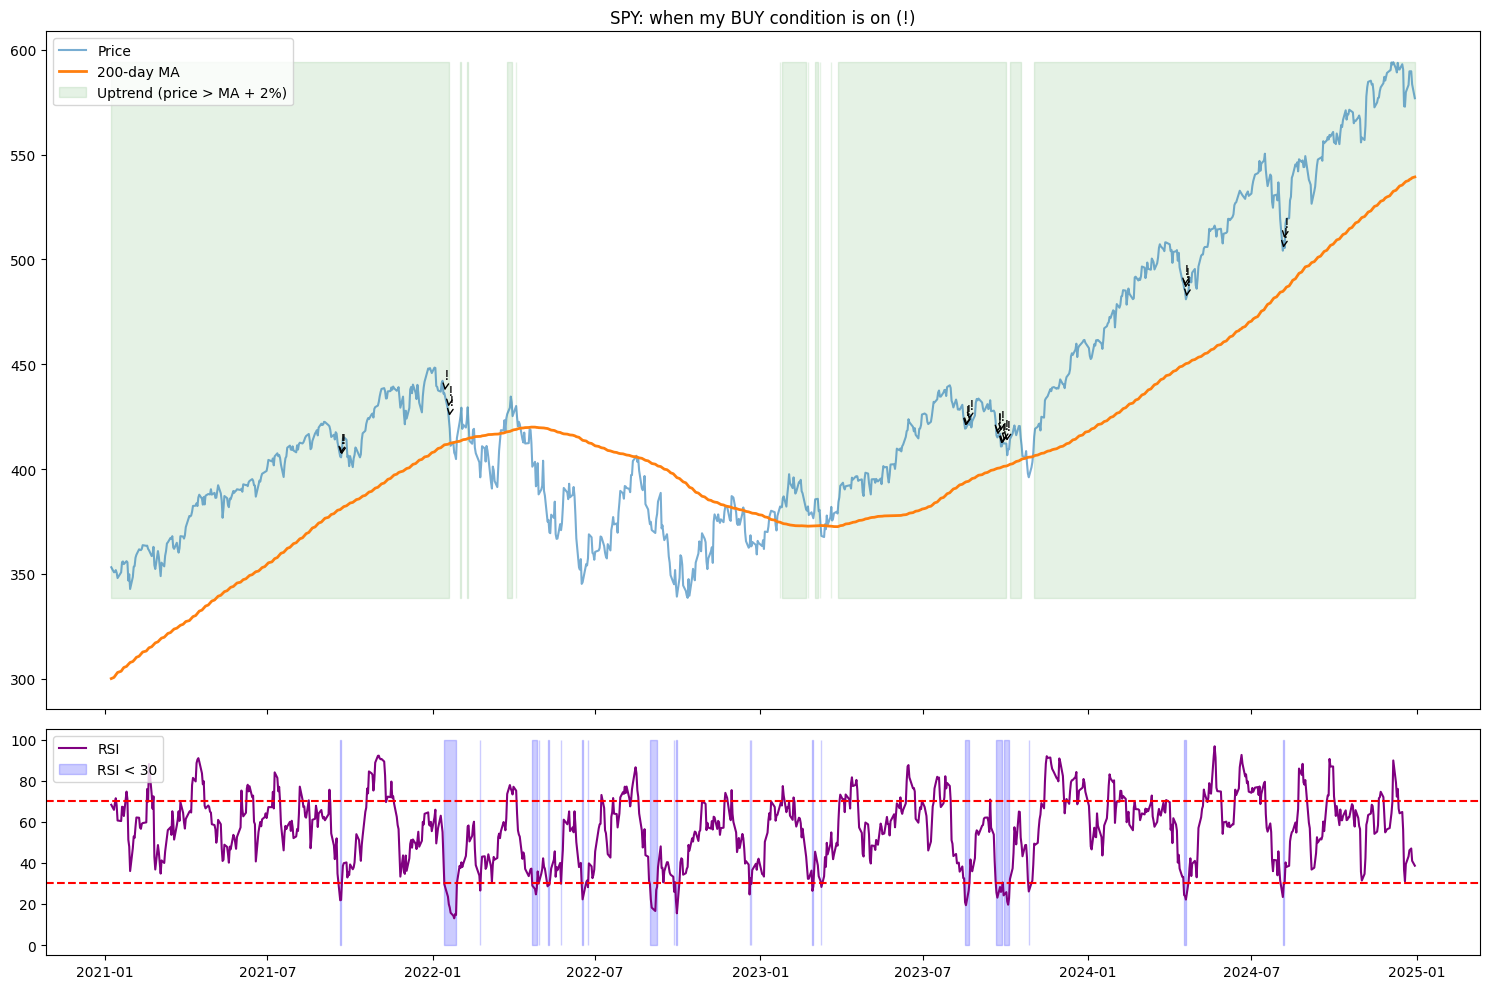

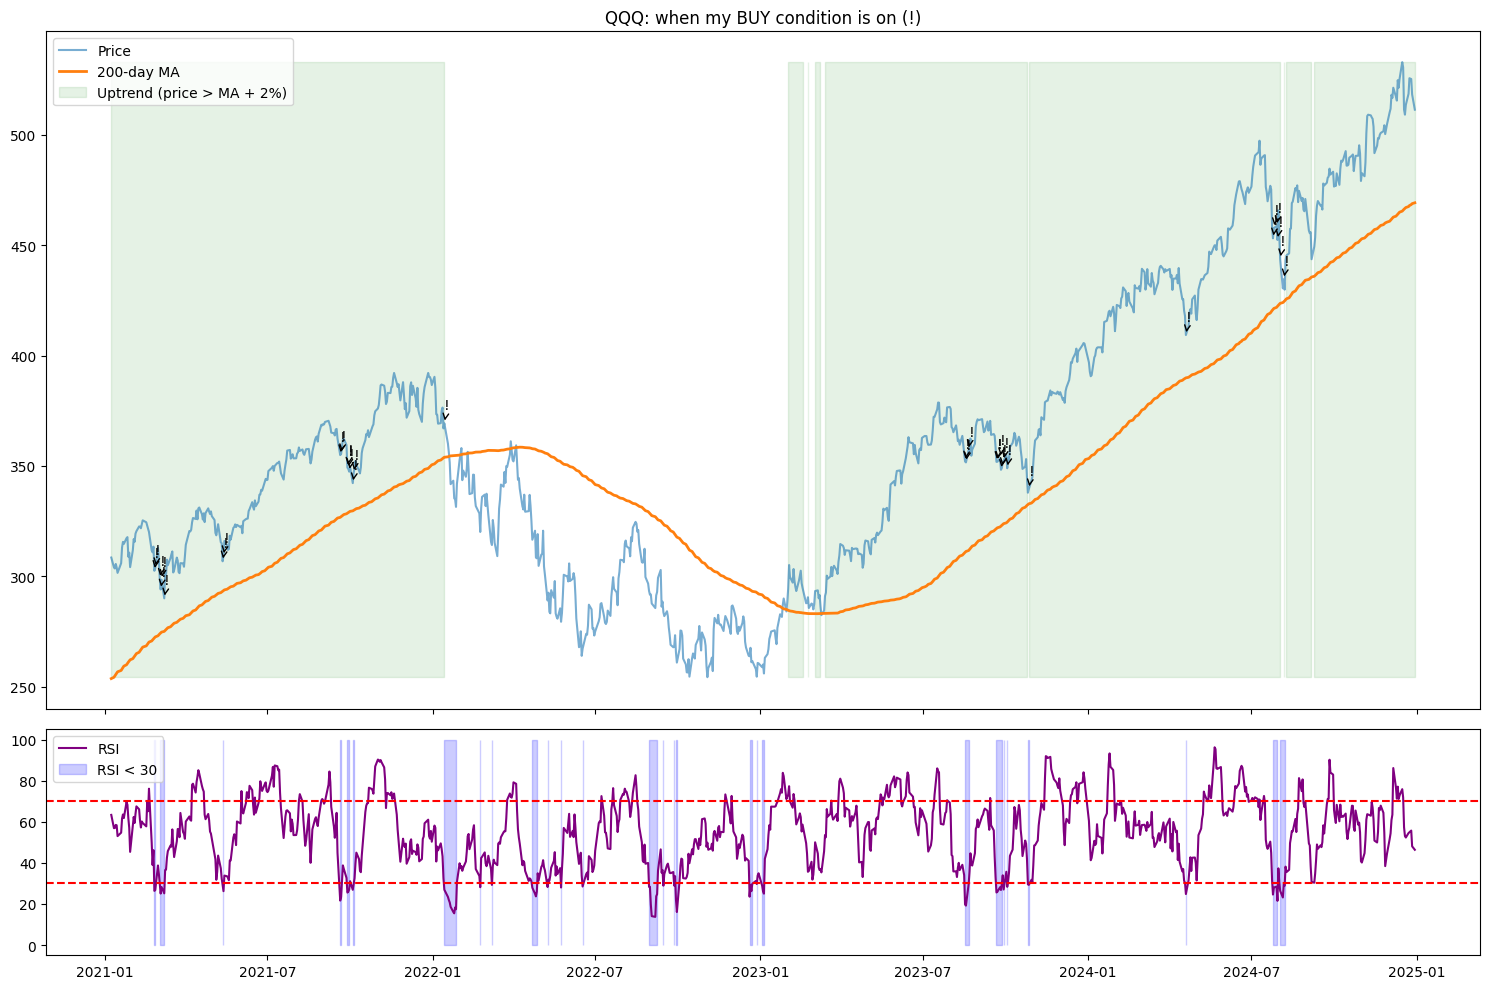

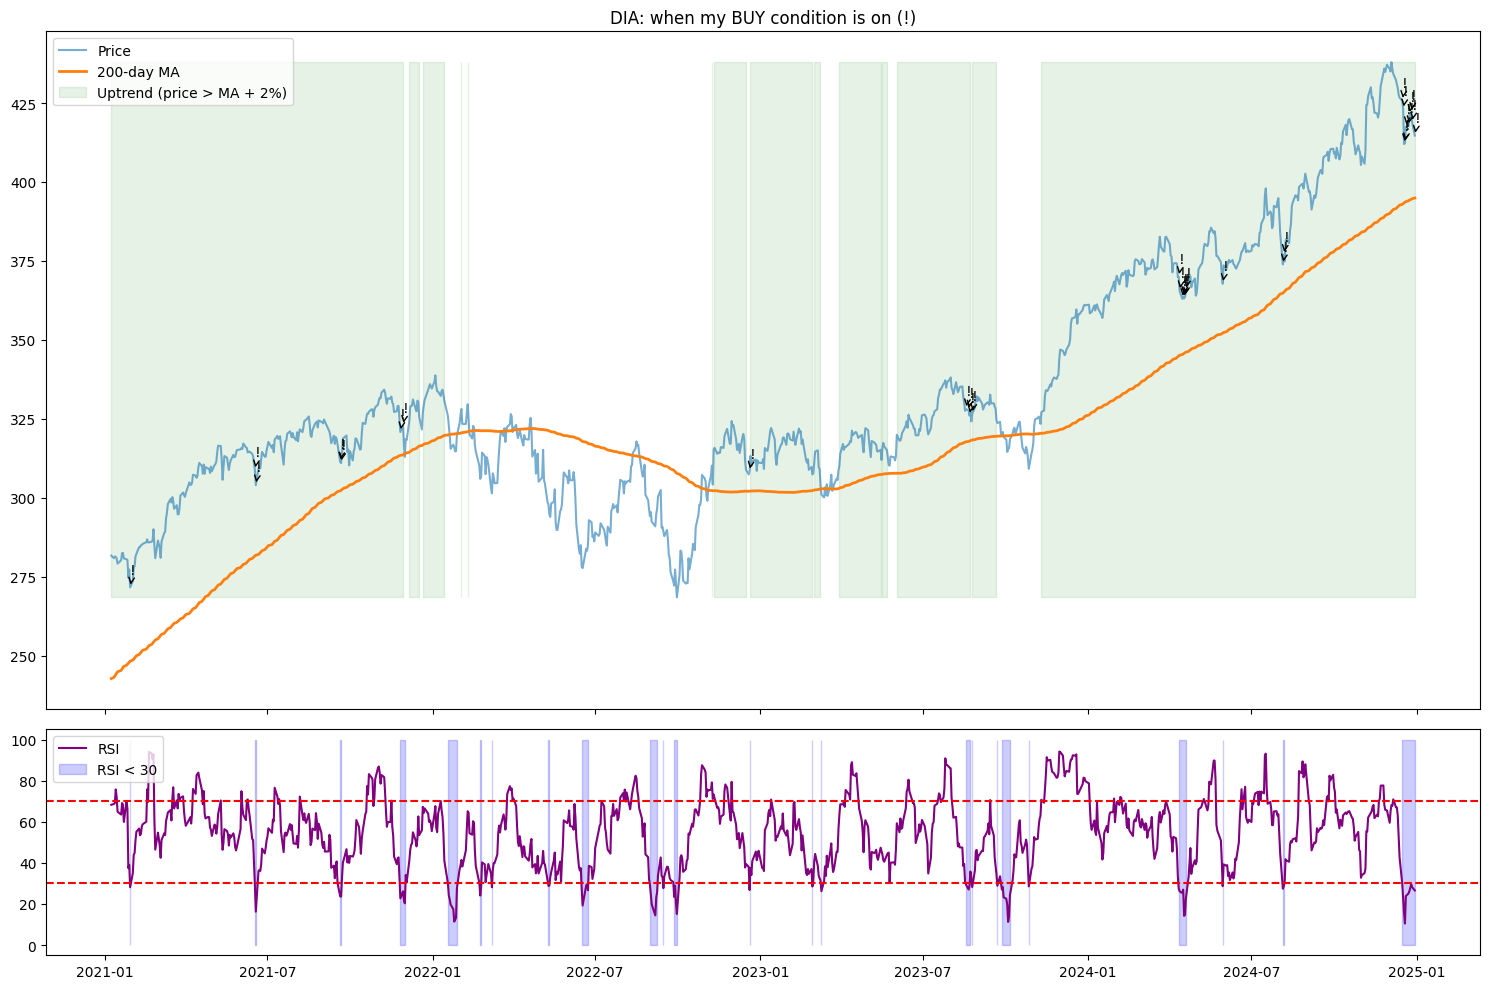

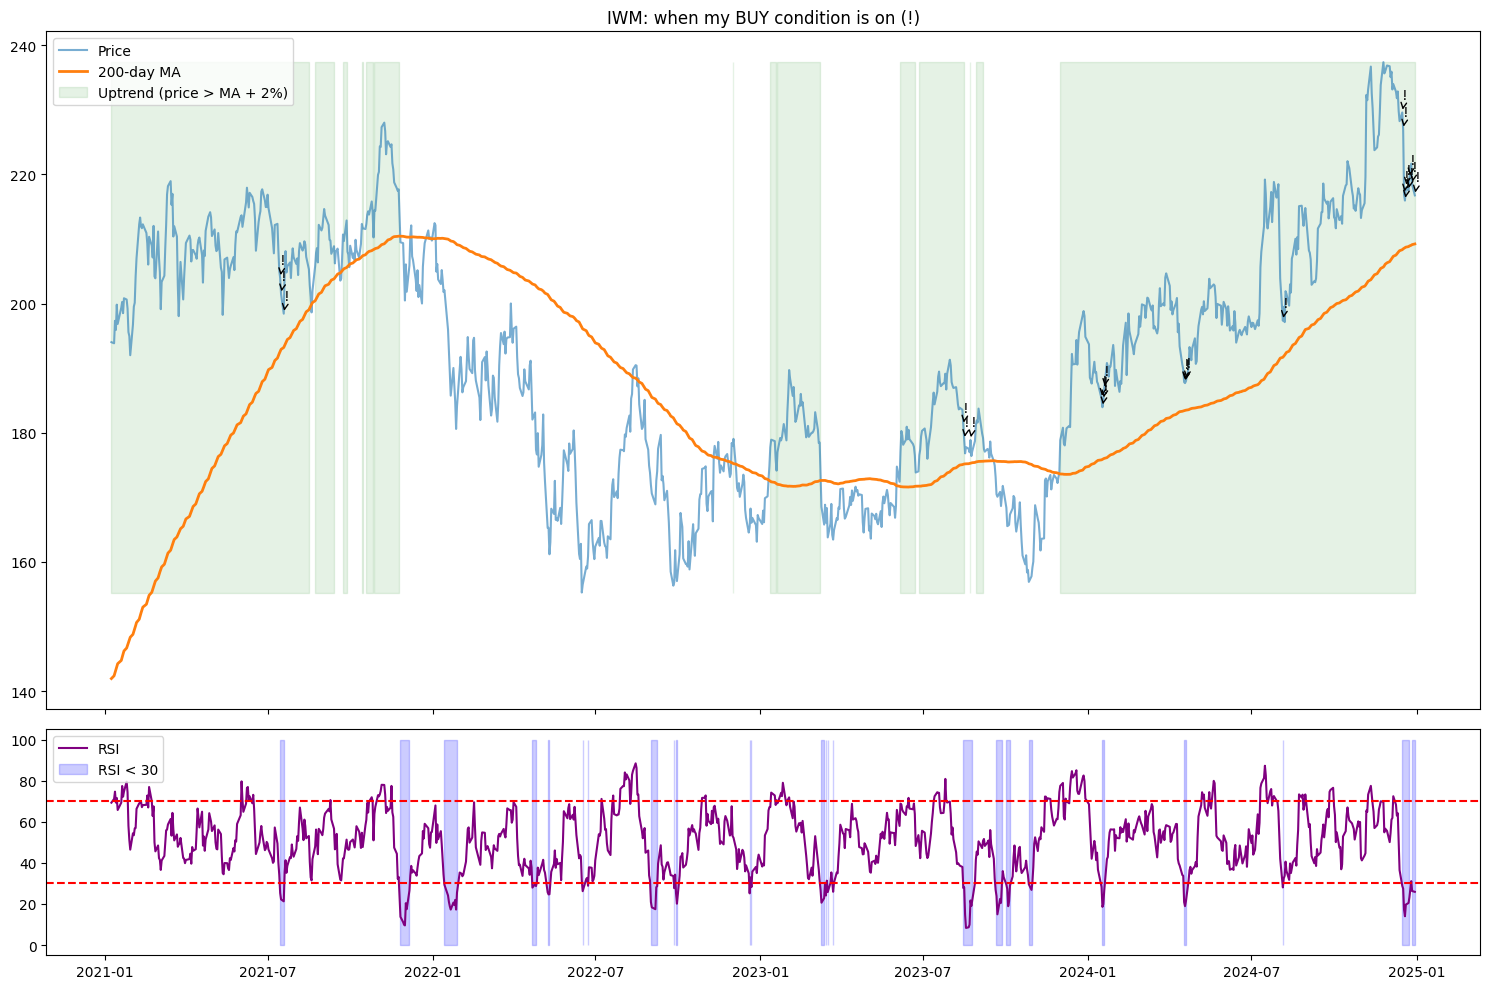

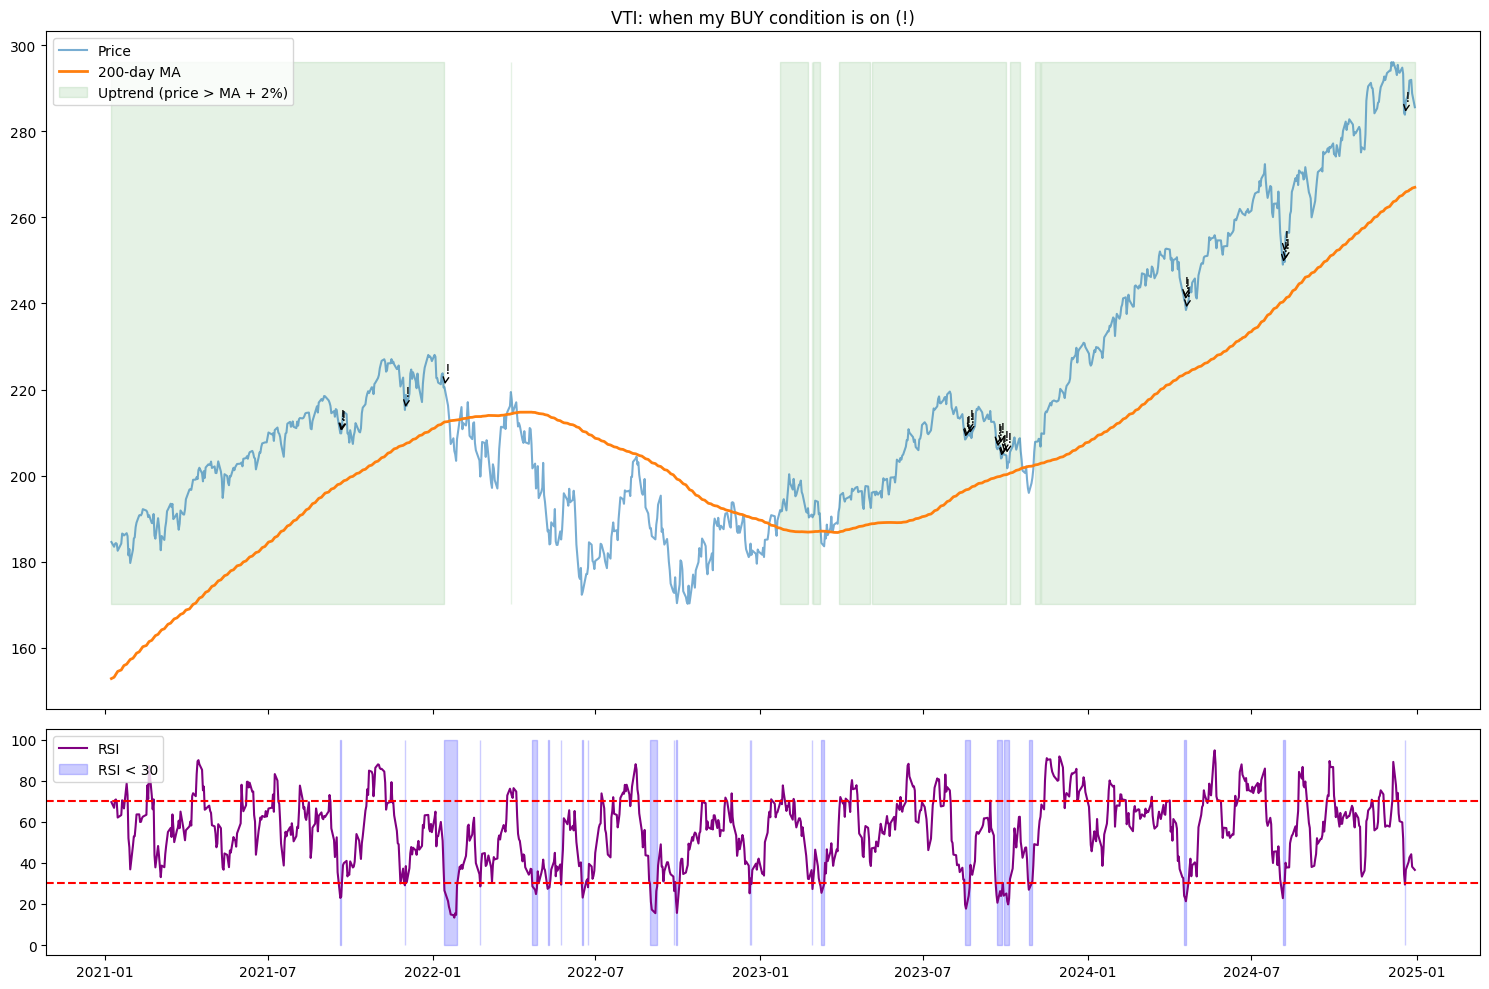

In [ ]:
def plot_confluence_signals(df, ticker, window_ma=200, rsi_os=30, rsi_ob=70, epsilon=0.02, days=1000):
    temp = calculate_rsi(df.copy())
    temp['MA'] = temp['Close'].rolling(window=window_ma).mean()
    uptrend = temp['Close'] > temp['MA'] * (1 + epsilon)
    oversold = temp['RSI'] < rsi_os
    buy_condition = uptrend & oversold

    # Only plot the last `days` days so it's readable
    temp, uptrend, oversold, buy_condition = temp.tail(days), uptrend.tail(days), oversold.tail(days), buy_condition.tail(days)

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 10), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    ax1.plot(temp.index, temp['Close'], label='Price', alpha=0.6)
    ax1.plot(temp.index, temp['MA'], label=f'{window_ma}-day MA', linewidth=2)
    ax1.fill_between(temp.index, temp['Close'].min(), temp['Close'].max(), where=uptrend,
                     color='green', alpha=0.1, label='Uptrend (price > MA + 2%)')
    for date in temp.index[buy_condition]:
        ax1.annotate('!', xy=(date, temp.loc[date, 'Close']), xytext=(0, 10),
                     textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))
    ax1.set_title(f'{ticker}: when my BUY condition is on (!)')
    ax1.legend(loc='upper left')

    ax2.plot(temp.index, temp['RSI'], color='purple', label='RSI')
    ax2.axhline(rsi_os, color='red', linestyle='--')
    ax2.axhline(rsi_ob, color='red', linestyle='--')
    ax2.fill_between(temp.index, 0, 100, where=oversold, color='blue', alpha=0.2, label='RSI < 30')
    ax2.legend(loc='upper left')
    plt.tight_layout()
    plt.show()

for t in TARGET_TICKERS:
    plot_confluence_signals(data_dict[t], t, window_ma=200, rsi_os=RSI_OVERSOLD, rsi_ob=RSI_OVERBOUGHT, epsilon=EPSILON)

## 4d. Each ETF separately
**Question:** Does the portfolio chart look the same for each ETF, or is it just QQQ?

**What to test:** Same growth chart as Section 3, one ETF at a time (buy & hold, 50/200-day MA, RSI, Confluence).

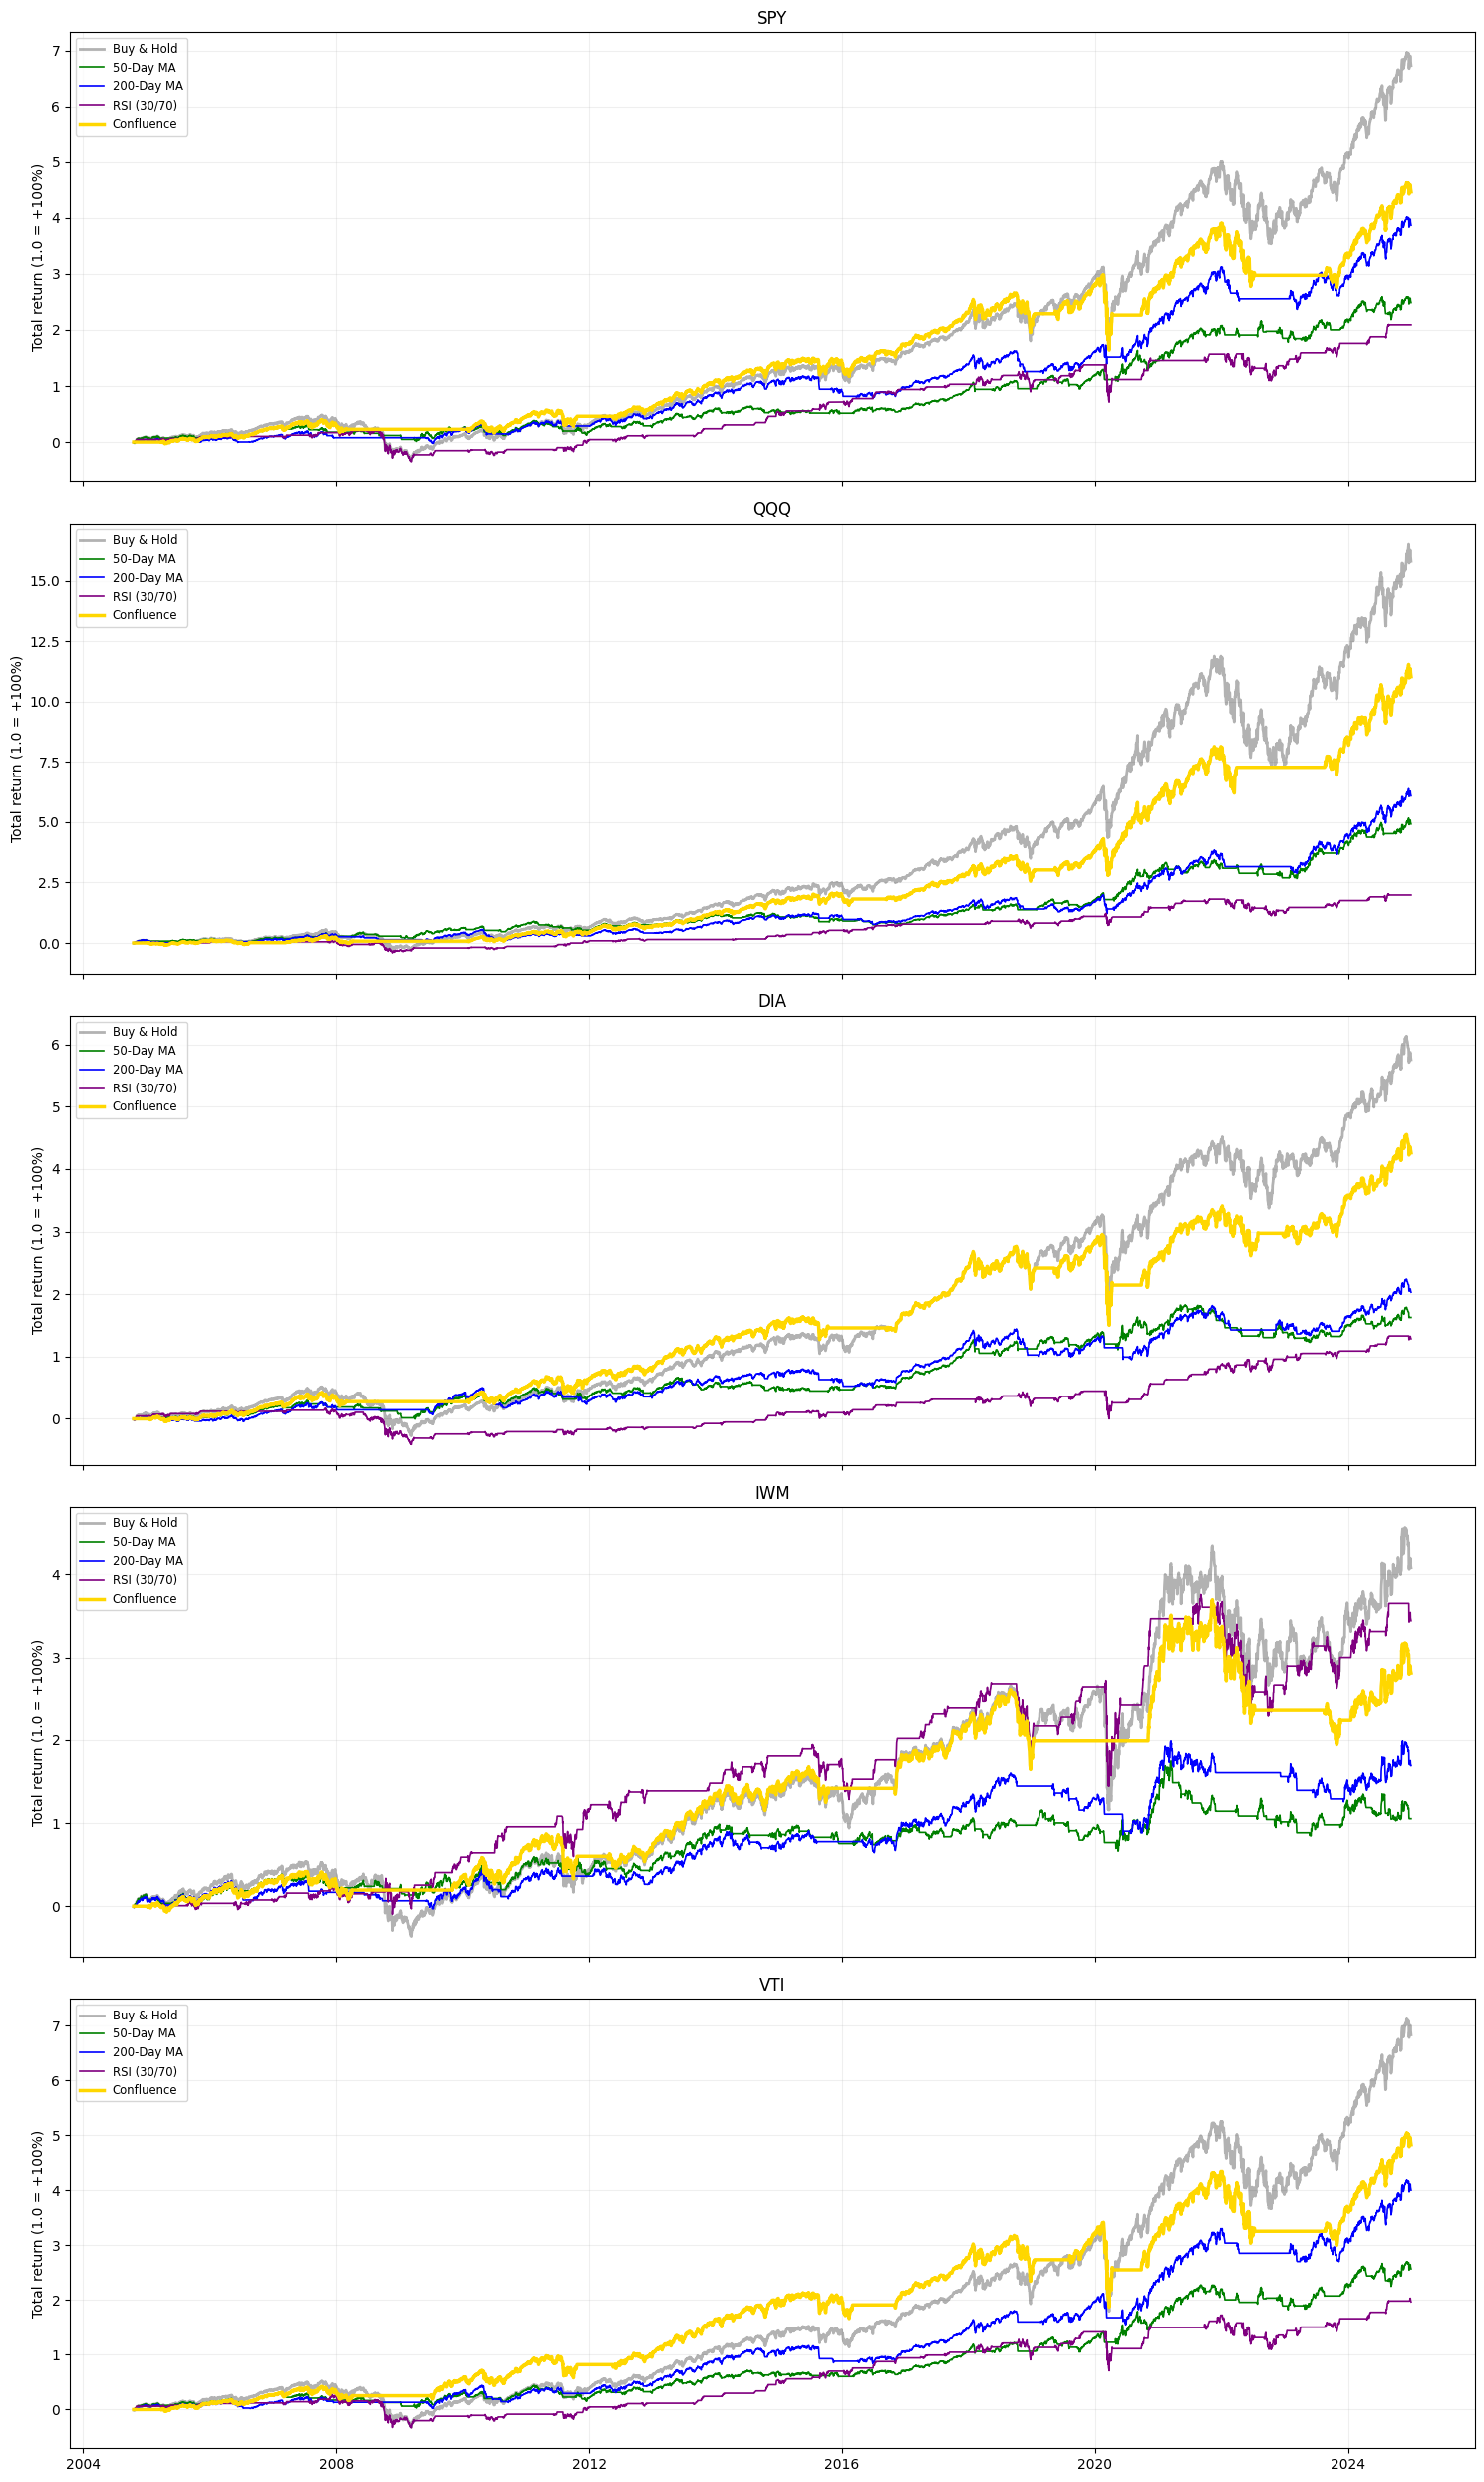

In [ ]:
fig, axes = plt.subplots(nrows=len(TARGET_TICKERS), ncols=1, figsize=(15, 5 * len(TARGET_TICKERS)), sharex=True)

for ax, t in zip(axes, TARGET_TICKERS):
    df = data_dict[t]
    bh = (1 + df['Close'].pct_change().iloc[WARM_UP:]).cumprod() - 1
    ax.plot(bh, label='Buy & Hold', color='black', linewidth=2, alpha=0.3)
    for name in ['50-Day MA', '200-Day MA', 'RSI (30/70)', 'Confluence']:
        daily = get_daily_strategy_returns(df, TRADES[(name, t)]).iloc[WARM_UP:]
        ax.plot((1 + daily).cumprod() - 1, label=name, color=COLORS[name],
                linewidth=2.5 if name == 'Confluence' else 1.2)
    ax.set_title(t)
    ax.set_ylabel('Total return (1.0 = +100%)')
    ax.legend(loc='upper left', fontsize='small')
    ax.grid(True, alpha=0.2)

plt.tight_layout()
plt.show()

# 5. Real edge or just luck?
**Question:** Confluence only made ~6 trades per ETF. Did it just get lucky with a few big trades?

**What to test:** For each strategy, randomly pick the same number of trades from its own list of trades (the same trade can be picked twice), then re-compound. Do this 2000 times. If the box is tall, the result depends a lot on which trades you happened to get.

**Notes:**
- Buy & hold is just 1 trade per ETF, so I can't shuffle it. It's the dashed line.
- This doesn't care how long each trade lasted.

--- Resampling trades (2000 runs) | Buy & Hold actual: 7.91 ---


,Trades,Actual Total Return,Resampled Median,Resampled Mean,Resampled Std Dev,Beats Buy & Hold (% of runs)
Confluence,32,5.48,6.22,7.16,3.82,30.25
200-Day MA,307,3.54,4.23,4.71,2.34,8.15
RSI (30/70),270,2.34,2.73,2.78,0.87,0.00
50-Day MA,315,2.33,2.69,2.93,1.33,0.70
100-Day MA,305,2.19,2.63,2.89,1.38,0.65
20-Day MA,422,1.90,2.30,2.54,1.31,0.65


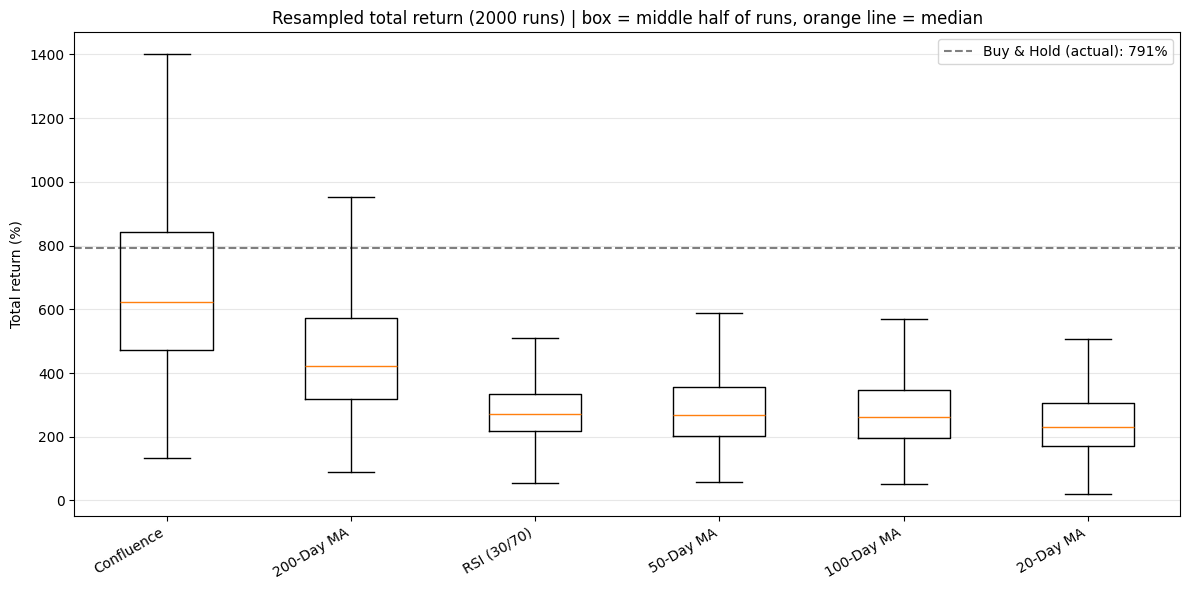

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_RESAMPLES = 2000
rng = np.random.default_rng(42)  # fixed seed so I get the same numbers every run

# 1. List of trade returns for each strategy, one list per ETF
trade_rets = {}
for name in STRATEGIES:
    trade_rets[name] = []
    for t in TARGET_TICKERS:
        r = calculate_trade_returns(TRADES[(name, t)])
        if not r.empty:
            trade_rets[name].append(r['Return_Pct'].to_numpy())

def total_return(per_ticker_trades):
    """Compound each ETF's trades, then average across ETFs."""
    return np.mean([np.prod(1 + r) - 1 for r in per_ticker_trades])

def resample(per_ticker_trades):
    """Randomly pick the same number of trades per ETF (repeats allowed)."""
    return [rng.choice(r, size=len(r), replace=True) for r in per_ticker_trades]

# 2. Resample 2000 times per strategy
results = pd.DataFrame({name: [total_return(resample(p)) for _ in range(N_RESAMPLES)]
                        for name, p in trade_rets.items()})

bh_actual = np.mean([data_dict[t]['Close'].iloc[-1] / data_dict[t]['Close'].iloc[WARM_UP] - 1
                     for t in TARGET_TICKERS])

summary = pd.DataFrame({
    'Trades': {n: sum(len(r) for r in p) for n, p in trade_rets.items()},
    'Actual Total Return': {n: total_return(p) for n, p in trade_rets.items()},
    'Resampled Median': results.median(),  # middle run, not pulled up by a few lucky runs
    'Resampled Mean': results.mean(),
    'Resampled Std Dev': results.std(),
    'Beats Buy & Hold (% of runs)': (results > bh_actual).mean() * 100,
}).sort_values('Actual Total Return', ascending=False)
print(f'--- Resampling trades ({N_RESAMPLES} runs) | Buy & Hold actual: {bh_actual:.2f} ---')
display(summary.round(2))

# 3. Box plot
order = list(summary.index)
fig, ax = plt.subplots(figsize=(12, 6))
ax.boxplot([results[n] * 100 for n in order], showfliers=False)
ax.set_xticks(range(1, len(order) + 1), order, rotation=30, ha='right')
ax.axhline(bh_actual * 100, color='black', linestyle='--', alpha=0.5,
           label=f'Buy & Hold (actual): {bh_actual * 100:.0f}%')
ax.set_ylabel('Total return (%)')
ax.set_title(f'Resampled total return ({N_RESAMPLES} runs) | box = middle half of runs, orange line = median')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### What I found (resampling)
| Strategy | Trades | Actual | Median | Mean | Beats B&H |
|---|---|---|---|---|---|
| Confluence | 32 | 548% | 622% | 716% | 30% of runs |
| 200-day MA | 307 | 354% | 423% | 471% | 8% |
| RSI (30/70) | 270 | 234% | 273% | 278% | 0% |
| 50-day MA | 315 | 233% | 269% | 293% | <1% |
| 100-day MA | 305 | 219% | 263% | 289% | <1% |
| 20-day MA | 422 | 190% | 230% | 254% | <1% |

Buy & hold actual: 791%.

- **Confluence depends the most on luck.** Tallest box by far (std dev 382% vs. 234% for the 200-day MA). With only 32 trades, which trades you get matters a lot.
- **Confluence vs. 200-day MA:** Confluence's median (622%) is higher than the 200-day MA's (423%) and its box sits mostly above it, but the boxes overlap. So it's *probably* better on return, not definitely.
- **Nothing reliably beats buy & hold on return.** Confluence beats it in ~30% of runs, the 200-day MA in ~8%, the rest almost never. The real win for these strategies is smaller drawdowns (~-24% to -34% vs. ~-55%), not more money.
- **Mean vs. median:** The mean is higher than the actual result for every strategy (Confluence +31%). With compounding, a few lucky runs with lots of big winners give huge numbers and pull the average up. The median is much closer (Confluence +13%), so I quote the median.

# 6. Conclusion
- **Nothing beat buy & hold on total return.** Buy & hold made ~791%. My best, Confluence, made ~548%, and the 200-day MA made ~354%. In the resampling test, Confluence beat buy & hold in only ~30% of runs.
- **What the strategies do buy you is smaller crashes.** Max drawdown was ~-24% (200-day MA) and ~-34% (Confluence) vs. ~-55% for buy & hold. Risk-adjusted (Sharpe), the 200-day MA and Confluence are only slightly better than buy & hold.
- **My Confluence strategy basically turned into buy & hold.** It almost never sells, so from 2009 to 2019 its line is right on top of buy & hold. It helped in 2008, but rode COVID all the way down.
- **More trading = worse.** The 20-day MA (most trades) did the worst, and the 2x ATR stop (way more trades) lost to the fixed stop.
- **Other settings don't change the main story** (Appendix A). Wider stops earn a bit more, but nothing gets close to buy & hold. One catch: Confluence only works with a long MA (150-200 days). With a 50-day MA it almost never trades.
- **So:** I'm sticking with buy & hold. If I couldn't handle a -55% drop, the 200-day MA is the one I'd consider, because it gets you through crashes with less pain. But you pay for it with a lot less money at the end.

# Appendix A: Do other settings change the story?
**Question:** When I was building this, I tried a few other values by hand (different buffer, stop, RSI levels) and nothing changed much, so I kept the standard ones (2% buffer, 5% stop, RSI 30/70, 200-day MA for Confluence). But I didn't write those tries down. Does that still hold if I test a lot of values properly?

**What to test:** Re-run with lots of other values and see if the results stay close.

**Important:** I'm **not** using these tables to pick the best settings. Whatever comes out on top in a table like this is partly luck (it was best on this exact data). What I want to see is that my settings are somewhere in the middle and the story doesn't change.

*(These cells take a few minutes to run.)*

In [ ]:
def summarize(trade_fn):
    """Run a strategy on all 5 ETFs and average the results (same method as Section 3)."""
    stats = []
    for t in TARGET_TICKERS:
        trades = trade_fn(data_dict[t])
        daily = get_daily_strategy_returns(data_dict[t], trades).iloc[WARM_UP:]
        stats.append({'Total Return': (1 + daily).prod() - 1,
                      'Max Drawdown': calculate_max_drawdown(daily),
                      'Sharpe Ratio': calculate_sharpe_ratio(daily),
                      'Trades': len(calculate_trade_returns(trades)) if not trades.empty else 0})
    stats = pd.DataFrame(stats)
    out = stats.mean()
    out['Trades'] = stats['Trades'].sum()
    return out

# Sweep 1: every MA length x lots of stop settings
STOP_SETTINGS = {
    'Fixed 3%': ('fixed', 0.03), 'Fixed 5%': ('fixed', 0.05), 'Fixed 8%': ('fixed', 0.08), 'Fixed 10%': ('fixed', 0.10),
    'ATR 2.0x': ('atr', 2.0), 'ATR 3.0x': ('atr', 3.0), 'ATR 3.5x': ('atr', 3.5), 'ATR 4.0x': ('atr', 4.0), 'ATR 5.0x': ('atr', 5.0),
}
rows = {}
for window in MA_WINDOWS:
    for stop_name, (kind, value) in STOP_SETTINGS.items():
        if kind == 'fixed':
            fn = lambda d, w=window, v=value: trade_ma_with_fixed_trailing_stop(d, w, epsilon=EPSILON, trailing_stop_pct=v)
        else:
            fn = lambda d, w=window, v=value: trade_ma_with_atr_stop(d, w, epsilon=EPSILON, atr_multiplier=v)
        rows[(window, stop_name)] = summarize(fn)

sweep_stops = pd.DataFrame(rows).T
sweep_stops.index.names = ['MA', 'Stop']
for metric in ['Total Return', 'Max Drawdown', 'Sharpe Ratio']:
    print(f'--- {metric}: MA length (rows) x stop (columns) ---')
    display(sweep_stops[metric].unstack()[list(STOP_SETTINGS)].round(2))

--- Total Return: MA length (rows) x stop (columns) ---


Stop,Fixed 3%,Fixed 5%,Fixed 8%,Fixed 10%,ATR 2.0x,ATR 3.0x,ATR 3.5x,ATR 4.0x,ATR 5.0x
MA,,,,,,,,,
20,1.39,1.99,2.16,2.17,1.25,1.55,1.76,1.75,1.91
50,1.45,2.53,2.52,2.43,1.51,2.01,2.06,1.96,2.20
100,2.13,2.25,2.67,2.85,1.94,2.36,2.31,2.05,2.07
200,3.12,3.54,3.90,4.26,2.87,3.46,3.59,3.46,3.58


--- Max Drawdown: MA length (rows) x stop (columns) ---


Stop,Fixed 3%,Fixed 5%,Fixed 8%,Fixed 10%,ATR 2.0x,ATR 3.0x,ATR 3.5x,ATR 4.0x,ATR 5.0x
MA,,,,,,,,,
20,-0.29,-0.32,-0.30,-0.30,-0.25,-0.30,-0.31,-0.30,-0.30
50,-0.26,-0.24,-0.26,-0.26,-0.22,-0.26,-0.26,-0.27,-0.26
100,-0.26,-0.26,-0.26,-0.28,-0.26,-0.26,-0.27,-0.27,-0.28
200,-0.23,-0.24,-0.26,-0.26,-0.26,-0.24,-0.26,-0.26,-0.27


--- Sharpe Ratio: MA length (rows) x stop (columns) ---


Stop,Fixed 3%,Fixed 5%,Fixed 8%,Fixed 10%,ATR 2.0x,ATR 3.0x,ATR 3.5x,ATR 4.0x,ATR 5.0x
MA,,,,,,,,,
20,0.41,0.48,0.50,0.50,0.40,0.44,0.45,0.44,0.46
50,0.43,0.56,0.56,0.55,0.45,0.50,0.49,0.48,0.52
100,0.53,0.53,0.55,0.56,0.51,0.54,0.53,0.50,0.49
200,0.61,0.64,0.66,0.67,0.55,0.61,0.62,0.60,0.64


In [ ]:
# Sweep 2: size of the buffer around the MA (200-day MA and Confluence)
rows = {}
for eps in [0.0, 0.01, 0.02, 0.03, 0.05]:
    rows[('200-Day MA', f'{eps:.0%}')] = summarize(
        lambda d, e=eps: trade_ma_with_fixed_trailing_stop(d, 200, epsilon=e, trailing_stop_pct=TRAILING_STOP_PCT))
    rows[('Confluence', f'{eps:.0%}')] = summarize(
        lambda d, e=eps: trade_confluence(d, window_ma=200, rsi_os=RSI_OVERSOLD, rsi_ob=RSI_OVERBOUGHT, epsilon=e))

sweep_buffer = pd.DataFrame(rows).T
sweep_buffer.index.names = ['Strategy', 'Buffer']
print('--- Buffer size (my setting: 2%) ---')
display(sweep_buffer.round(2))

--- Buffer size (my setting: 2%) ---


,,Total Return,Max Drawdown,Sharpe Ratio,Trades
Strategy,Buffer,,,,
200-Day MA,0%,3.45,-0.27,0.62,559.0
Confluence,0%,5.53,-0.33,0.69,37.0
200-Day MA,1%,3.51,-0.25,0.63,374.0
Confluence,1%,5.58,-0.34,0.67,35.0
200-Day MA,2%,3.54,-0.24,0.64,307.0
Confluence,2%,5.48,-0.34,0.66,32.0
200-Day MA,3%,3.12,-0.24,0.62,284.0
Confluence,3%,4.73,-0.35,0.63,27.0
200-Day MA,5%,2.32,-0.21,0.54,246.0


In [ ]:
# Sweep 3: Confluence with different MA lengths and RSI levels
rows = {}
for window in [50, 100, 150, 200]:
    for os_level, ob_level in [(20, 80), (30, 70), (40, 60)]:
        rows[(window, f'{os_level}/{ob_level}')] = summarize(
            lambda d, w=window, a=os_level, b=ob_level: trade_confluence(d, window_ma=w, rsi_os=a, rsi_ob=b, epsilon=EPSILON))

sweep_confluence = pd.DataFrame(rows).T
sweep_confluence.index.names = ['MA', 'RSI levels']
print('--- Confluence settings (mine: 200-day MA, RSI 30/70) ---')
display(sweep_confluence.round(2))

--- Confluence settings (mine: 200-day MA, RSI 30/70) ---


Total Return  Max Drawdown  Sharpe Ratio  Trades
MA  RSI levels                                                  
50  20/80               0.00          0.00          0.00     0.0
    30/70               0.04         -0.02          0.04     1.0
    40/60               2.07         -0.35          0.50    26.0
100 20/80               0.27         -0.08          0.32     4.0
    30/70               2.36         -0.43          0.44    22.0
    40/60               4.30         -0.40          0.63    55.0
150 20/80               2.58         -0.26          0.49     5.0
    30/70               4.98         -0.34          0.65    32.0
    40/60               4.76         -0.35          0.66    46.0
200 20/80               4.45         -0.48          0.59    10.0
    30/70               5.48         -0.34          0.66    32.0
    40/60               5.65         -0.36          0.68    41.0

### What I found (settings)
- **Stops: wider = more return, for every MA.** The 200-day MA made ~426% with a 10% stop vs. ~354% with 5%. That makes sense: a wider stop means fewer trades, so it's closer to buy & hold. But even the best one is way below buy & hold (791%).
- **The stop barely changes the crash protection.** Max drawdown stays around -23% to -27% for the 200-day MA no matter which stop. The MA line is what gets you out of crashes, not the stop.
- **The 200-day MA is the best MA with every stop I tried**, and ATR 2.0x is at or near the bottom every time. My 5% stop is in the middle, not the best.
- **Buffer: 0-2% are about the same** (200-day MA ~345-354%, Confluence ~548-558%). 5% hurts the 200-day MA (~232%). With no buffer at all, the 200-day MA makes 559 trades vs. 307 for about the same return.
- **Confluence is picky about the MA length. This is the biggest thing I found here.** With RSI 30/70: 200-day ~548%, 150-day ~498%, 100-day ~236%, 50-day ~4% (1 trade in 20 years across all 5 ETFs!). My guess: with a short MA, a dip big enough to push RSI under 30 also pushes price under the MA, so both conditions are almost never true together.
- **Near my settings, Confluence is stable.** 200-day with 40/60 made ~565%, right next to mine (~548%). Still below buy & hold.
- **So:** the main story holds for every setting I tried. Nothing beats buy & hold on return, and the MA strategies cut the crashes. But Confluence only works with a long MA, so it's not as "general" as I thought.

# Appendix B: Sanity checks
Stuff I used to double-check the code. Not part of the main story.

**Check 1: Total return two ways.** Adding up trade-by-trade should match the daily method in Section 3. It should match exactly for the 200-day MA and Confluence. The 20/50/100-day MAs and RSI can be a bit different, because they can start trading during the first 200 days, which Section 3 skips.

In [ ]:
rows = []
for name in STRATEGIES:
    for t in TARGET_TICKERS:
        rets = calculate_trade_returns(TRADES[(name, t)])
        if not rets.empty:
            rows.append({'Strategy': name, 'Ticker': t, 'Trade-by-trade': (1 + rets['Return_Pct']).prod() - 1})

check = pd.DataFrame(rows).groupby('Strategy')[['Trade-by-trade']].mean()
check['Daily (Section 3)'] = main_summary['Total Return']
check['Difference'] = check['Trade-by-trade'] - check['Daily (Section 3)']
display(check.round(4))

,Trade-by-trade,Daily (Section 3),Difference
Strategy,,,
100-Day MA,2.1937,2.2500,-0.0563
20-Day MA,1.8985,1.9884,-0.0899
200-Day MA,3.5373,3.5373,0.0000
50-Day MA,2.3348,2.5317,-0.1969
Confluence,5.4801,5.4801,0.0000
RSI (30/70),2.3376,2.1541,0.1835


**Check 2: RSI values look right.** Last few days of SPY: RSI should be between 0 and 100 and roughly match what charting websites show.

In [ ]:
spy_rsi = calculate_rsi(data_dict['SPY'].copy())
display(spy_rsi[['Close', 'RSI']].tail(5).round(2))

Price,Close,RSI
Date,,
2024-12-23,583.23,43.15
2024-12-24,589.71,46.10
2024-12-26,589.75,46.98
2024-12-27,583.55,40.97
2024-12-30,576.89,38.60
